# Quasi-Normal Excitation Coefficients (QNECs) in black hole ringdown

In this notebook we compute the excitation coefficients $C_n$ of quasi-normal modes (QNMs) for a Schwarzschild black hole, using Gaussian initial data.

We consider two cases:

- A simple Gaussian pulse
- An oscillating Gaussian pulse

The goal is to study how the excitation of QNMs depends on the properties of the initial perturbation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import rw_solver as rw
from scipy.signal import find_peaks
from matplotlib.lines import Line2D

## Initial data

We consider Gaussian initial data:

$$
f(s) = A \exp\left(-\frac{(s-r_0)^2}{2\sigma^2}\right)\cos\left(\omega_0 (s-r_0)\right)
$$

Two cases:
- $\omega_0 = 0$
- $\omega_0 \neq 0$

In [2]:
# PARAMETERS

A_init = 1.0
r0 = 100.0

l_mode = 2
Mbh = 1.0

global_fac = -2.0
nsigma_pad = 10.0
Nmax = 300
e_spin = 3.0

r_obs_target = 100

omegas = np.array([
    0.3736716844180416 - 0.08896231568893692j,
    0.34671099687916285 - 0.27391487529123504j,
    0.30105345461250427 - 0.47827698322307044j,
    0.25150496222643026 - 0.7051482024421033j,
], dtype=complex)

B_list = np.array([
    1.269024e-1 + 2.031517e-2j,
    4.768259e-2 - 2.237546e-1j,
    -1.902843e-1 + 1.574857e-2j,
    8.086762e-2 + 7.961260e-2j,
], dtype=complex)

N_modes = len(B_list)

## Numerical setup

We evolve the initial data numerically and construct the tortoise coordinate grid.

In [3]:
sigma = 1.0
w0_init = 0.0

x_min, x_max = -200, 1000
Ngrid = 8000
TF = 500.0

Psi0 = rw.gaussiana(A_init, x_min, x_max, Ngrid, w0_init, r0, sigma)

U, T, s = rw.simula_full(
    N=Ngrid,
    x_min=x_min,
    x_max=x_max,
    Psi_initial=Psi0,
    TF=TF,
    CFL=0.1,
    l=l_mode,
    M=Mbh
)

s = np.array(s, float)
ds = s[1] - s[0]

r_areal = rw.r_of_s(s, M=Mbh)
r_obs_areal = rw.r_of_s(np.array([r_obs_target]), M=Mbh)[0]

## Leaver method

We construct the radial solutions $\psi_n(r)$ corresponding to each quasi-normal mode frequency $\omega_n$ using Leaver’s method, which provides a semi-analytic solution of the homogeneous radial equation.

---

### Radial equation

The perturbations satisfy a Schrödinger-like equation in the tortoise coordinate:

$$
\frac{d^2 \psi}{ds^2} + \left(\omega^2 - V(s)\right)\psi = 0
$$

After transforming to the areal radius $r$, one obtains an equation with regular singular points at:

- the horizon: $r = 2M$
- infinity: $r \to \infty$

---

### Series ansatz

Leaver’s method constructs the solution as a power series around infinity using the variable:

$$
z = 1 - \frac{1}{r}
$$

The solution is written as:

$$
\psi(r) = z^{2p} \sum_{n=0}^{\infty} a_n z^n
$$

where:

$$
p = -i \omega M \times 2 = -i \omega \bar{M}
$$

(with $\bar{M} = 2M$ in our notation).

---

### Recurrence relation

The coefficients $a_n$ satisfy a three-term recurrence relation:

$$
\alpha_n a_{n+1} + \beta_n a_n + \gamma_n a_{n-1} = 0
$$

with:

$$
\alpha_n = n^2 + (2p + 2)n + (2p + 1)
$$

$$
\beta_n = -\left[2n^2 + (8p + 2)n + 8p^2 + 4p + l(l+1) - e\right]
$$

$$
\gamma_n = n^2 + 4pn + 4p^2 - e - 1
$$

Here $l$ is the angular number and $e$ depends on the spin of the perturbation (for gravitational perturbations, $e=3$).

---

### Numerical computation (Miller algorithm)

To compute the coefficients $a_n$, we use backward recursion (Miller’s algorithm):

1. Set:
$$
a_{N_{\max}} = 1, \quad a_{N_{\max}+1} = 0
$$

2. Iterate backwards:
$$
a_{n-1} = -\frac{\beta_n a_n + \alpha_n a_{n+1}}{\gamma_n}
$$

3. Normalize by imposing:
$$
a_0 = 1
$$

---

### Final normalized solution

The radial solution is then reconstructed as:

$$
\psi_n(r) = z^{2p} \frac{\sum_{k=0}^{N_{\max}} a_k z^k}{\sum_{k=0}^{N_{\max}} a_k}
$$

This normalization ensures:

$$
\psi_n(r \to \infty) \to 1
$$

---

### Physical boundary conditions

Leaver’s construction automatically enforces the quasi-normal mode boundary conditions:

- **Purely ingoing** at the horizon:
  $$
  \psi \sim e^{-i \omega s}, \quad s \to -\infty
  $$

- **Purely outgoing** at infinity:
  $$
  \psi \sim e^{+i \omega s}, \quad s \to +\infty
  $$

---

The functions $\psi_n(r)$ encode the spatial structure of each quasi-normal mode and enter directly in the overlap integral:

$$
I_n = \int ds \, e^{i \omega_n s} \, \psi_n(s) \, q(s)
$$

Thus, Leaver’s method allows us to compute the **exact projection of the initial data onto the QNM basis**, beyond the asymptotic approximation $\psi_n \approx 1$.

In [4]:
def leaver_an_coeffs(omega, l, M=1.0, e=e_spin, Nmax=300):

    omega_bar = 2.0 * M * complex(omega)
    p = -1j * omega_bar

    def alpha(n):
        return n*n + (2*p + 2)*n + (2*p + 1)

    def beta(n):
        return -(2*n*n + (8*p + 2)*n + 8*p*p + 4*p + l*(l+1) - e)

    def gamma(n):
        return n*n + 4*p*n + 4*p*p - e - 1

    a = np.zeros(Nmax+2, dtype=complex)
    a[Nmax] = 1.0

    for n in range(Nmax, 0, -1):
        a[n-1] = -(beta(n)*a[n] + alpha(n)*a[n+1]) / gamma(n)

    return a[:Nmax+1] / a[0]


def psi_leaver_norm(omega, r_areal):

    r_bar = np.asarray(r_areal) / (2*Mbh)
    z = 1.0 - 1.0/r_bar

    a = leaver_an_coeffs(omega, l_mode, Mbh)

    Sz = np.zeros_like(z, dtype=complex)
    for an in a[::-1]:
        Sz = Sz*z + an

    S1 = np.sum(a)
    p = -1j * (2*Mbh*omega)

    return np.exp((2*p)*np.log(z)) * (Sz / S1)

## Core computation

The central step of the computation consists in projecting the initial data onto the quasi-normal mode (QNM) basis in order to extract the excitation coefficients $C_n$.

---

### Initial data

We start from the initial conditions:

$$
\Psi(t=0,s) = f(s), \qquad \partial_t \Psi(t=0,s) = g(s)
$$

From these, we construct the combination:

$$
q(s) = i \omega_n f(s) - g(s)
$$

This quantity naturally appears when expressing the solution in terms of Fourier-like modes and is the relevant object for the projection onto QNMs.

---

### Overlap integral

The excitation of each mode is determined by the overlap integral:

$$
I_n = \int ds \; e^{i \omega_n s} \, \psi_n(s) \, q(s)
$$

where:
- $\psi_n(s)$ is the radial solution computed via Leaver’s method
- $e^{i\omega_n s}$ accounts for the phase structure of the mode
- $q(s)$ encodes the initial data

This integral measures how well the initial perturbation matches the spatial profile of each quasi-normal mode.

---

### Asymptotic approximation

For comparison, we also consider the asymptotic approximation:

$$
I_n^{\text{asy}} = \int ds \; e^{i \omega_n s} \, q(s)
$$

which corresponds to assuming:

$$
\psi_n(s) \approx 1
$$

This approximation neglects the radial structure of the mode and is expected to be valid when the initial data is localized far from the potential barrier.

---

### Excitation coefficients

The final excitation coefficients are constructed as:

$$
C_n = \mathcal{N} \, B_n \, \psi_n(r_{\text{obs}}) \, I_n \, e^{-i \omega_n r_0}
$$

where:
- $B_n$ are normalization constants associated with each mode
- $\psi_n(r_{\text{obs}})$ evaluates the mode at the observation radius
- $e^{-i \omega_n r_0}$ is a phase factor accounting for the initial position of the pulse
- $\mathcal{N}$ is an overall normalization constant

Similarly, the asymptotic coefficients are:

$$
C_n^{\text{asy}} = \mathcal{N} \, B_n \, I_n^{\text{asy}} \, e^{-i \omega_n r_0}
$$

---

### Numerical implementation

The computation is carried out in the following steps:

1. **Restrict the integration domain**  
   The integral is evaluated only in the region where the initial pulse has support:
   $$
   s \in [r_0 - N_\sigma \sigma,\; r_0 + N_\sigma \sigma]
   $$

2. **Compute the integrand**  
   For each mode:
   - evaluate $\psi_n(s)$ using Leaver’s method
   - construct $q(s)$
   - build the oscillatory factor $e^{i \omega_n s}$

3. **Perform numerical integration**  
   The integral is computed using a trapezoidal rule:
   $$
   I_n \approx \sum_i \Delta s \, e^{i \omega_n s_i} \psi_n(s_i) q(s_i)
   $$

---

The coefficient $C_n$ quantifies how strongly each quasi-normal mode is excited by the initial perturbation.

- Large $|C_n|$ → strong excitation of mode $n$
- Small $|C_n|$ → weak contribution to the ringdown

Thus, this procedure provides a direct link between:
- the **initial data** $(f,g)$  
- and the **observable ringdown signal**

In [5]:
def build_initial_data(sigma, w0):

    f = A_init * np.exp(-(s - r0)**2 / (2 * sigma**2)) * np.cos(w0 * (s - r0))
    g = rw.d1_4th(f, ds)

    mask = (s >= r0 - nsigma_pad*sigma) & (s <= r0 + nsigma_pad*sigma)

    return s[mask], r_areal[mask], f[mask], g[mask]


def compute_Cn_for_pulse(sigma, w0):

    C_exact = np.zeros(N_modes, dtype=complex)
    C_asy   = np.zeros(N_modes, dtype=complex)

    s_int, r_int, f_int, g_int = build_initial_data(sigma, w0)

    for n, om in enumerate(omegas):

        q = 1j * om * f_int - g_int

        psi_int = psi_leaver_norm(om, r_int)
        psi_obs = psi_leaver_norm(om, [r_obs_areal])[0]

        exp_term = np.exp(1j * om * s_int)

        I_exact = np.trapz(exp_term * psi_int * q, s_int)
        I_asy   = np.trapz(exp_term * q, s_int)

        phase = np.exp(-1j * om * r0)

        C_exact[n] = global_fac * B_list[n] * psi_obs * I_exact * phase
        C_asy[n]   = global_fac * B_list[n] * I_asy * phase

    return C_exact, C_asy

## Gaussian pulse (σ sweep)

In [6]:
sigma_values = np.arange(0.01, 10.0, 0.01)

C_exact_sigma = np.zeros((len(sigma_values), N_modes), dtype=complex)
C_asy_sigma   = np.zeros_like(C_exact_sigma)

for i, sigma in enumerate(sigma_values):
    C_exact_sigma[i], C_asy_sigma[i] = compute_Cn_for_pulse(sigma, 0.0)

/var/folders/4w/llt2155x2g31xxdrldln6zxh0000gp/T/ipykernel_84969/1882647380.py:27: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  I_exact = np.trapz(exp_term * psi_int * q, s_int)
/var/folders/4w/llt2155x2g31xxdrldln6zxh0000gp/T/ipykernel_84969/1882647380.py:28: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  I_asy   = np.trapz(exp_term * q, s_int)


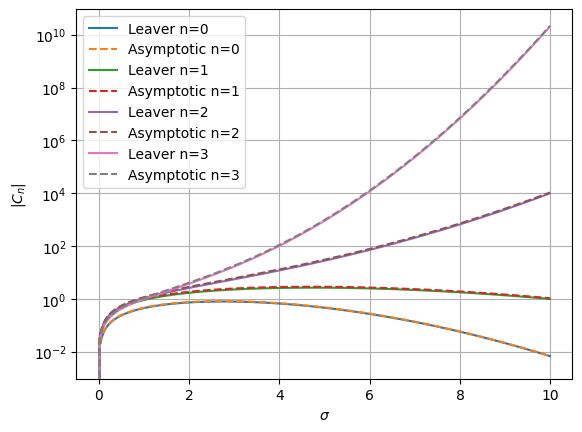

In [7]:
plt.figure()

for n in range(4):
    plt.plot(sigma_values, np.abs(C_exact_sigma[:,n]),label=f"Leaver n={n}")
    plt.plot(sigma_values, np.abs(C_asy_sigma[:,n]), "--",label=f"Asymptotic n={n}")

plt.yscale("log")
plt.xlabel(r"$\sigma$")
plt.ylabel(r"$|C_n|$")
plt.legend()
plt.grid(True)
plt.show()

## Oscillating Gaussian pulse (frequency sweep)

In [8]:
sigma = 5.0
w0_values = np.arange(0.0, 1.0, 0.001)

C_exact_freq = np.zeros((len(w0_values), N_modes), dtype=complex)
C_asy_freq   = np.zeros_like(C_exact_freq)

for i, w0 in enumerate(w0_values):
    C_exact_freq[i], C_asy_freq[i] = compute_Cn_for_pulse(sigma, w0)

/var/folders/4w/llt2155x2g31xxdrldln6zxh0000gp/T/ipykernel_84969/1882647380.py:27: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  I_exact = np.trapz(exp_term * psi_int * q, s_int)
/var/folders/4w/llt2155x2g31xxdrldln6zxh0000gp/T/ipykernel_84969/1882647380.py:28: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  I_asy   = np.trapz(exp_term * q, s_int)


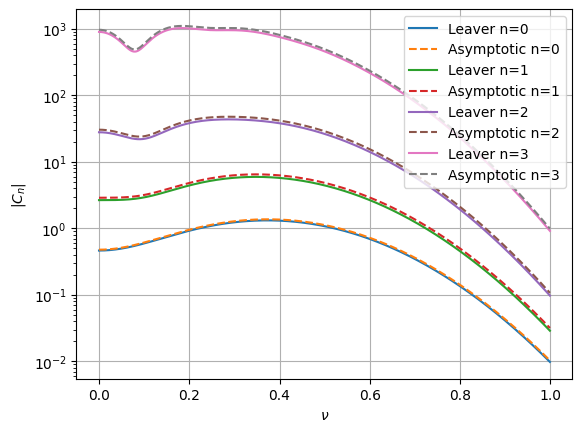

In [9]:
plt.figure()

for n in range(4):

    plt.plot(w0_values, np.abs(C_exact_freq[:,n]), label=f"Leaver n={n}")
    plt.plot(w0_values, np.abs(C_asy_freq[:,n]), "--",label=f"Asymptotic n={n}")

plt.yscale("log")
plt.xlabel(r"$\nu$")
plt.ylabel(r"$|C_n|$")
plt.legend()
plt.grid(True)
plt.show()